<a href="https://colab.research.google.com/github/noone878/data-science-2026/blob/main/Pertemuan7_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
# NAMA  : SEPTIAN AL RIZKI
# NIM   : 230401010262
# KELAS : IF401

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

=== LANGKAH 1: MEMBUAT DATASET & EKSPLORASI (EDA) ===
-> 5 Baris Pertama Dataset Asli:


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


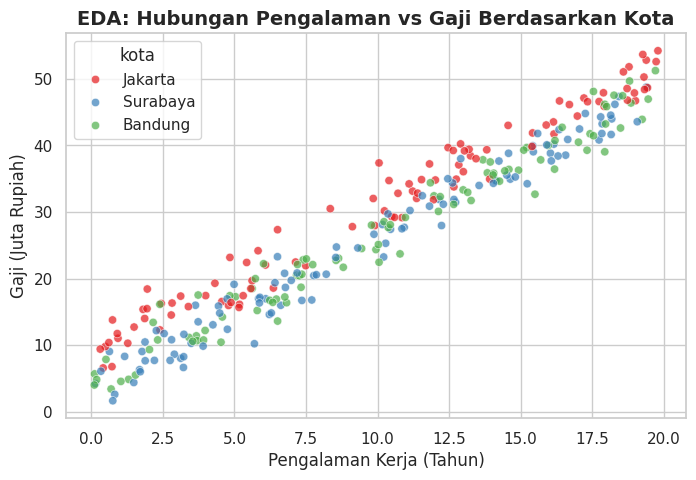

In [46]:
# ── 1. GENERATE DATASET SINTETIS
print("=== LANGKAH 1: MEMBUAT DATASET & EKSPLORASI (EDA) ===")
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)

# Rumus Gaji: Gaji Dasar + Pengalaman + Edukasi + Bonus Jakarta + Noise Acak
gaji = (3.0 + 2.2 * pengalaman + 1.5 * edu +
        np.where(kota=='Jakarta', 4.0, 0) +
        np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman': pengalaman, 'edu': edu, 'kota': kota, 'gaji': gaji})

print("-> 5 Baris Pertama Dataset Asli:")
display(df.head())

# Plot EDA
sns.set_theme(style='whitegrid', palette='muted')
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set1', alpha=0.7)
plt.title('EDA: Hubungan Pengalaman vs Gaji Berdasarkan Kota', fontsize=14, fontweight='bold')
plt.xlabel('Pengalaman Kerja (Tahun)')
plt.ylabel('Gaji (Juta Rupiah)')
plt.show()

print("\n" + "="*60 + "\n")

In [47]:
# ── 2. PREPROCESSING
print("=== LANGKAH 2: PREPROCESSING DATA ===")
# a. One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['kota'], drop_first=True)
print(f"-> Ukuran data setelah One-Hot Encoding: {df_encoded.shape}")

X = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

# b. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"-> Data Latih (Train) : {X_train.shape[0]} baris")
print(f"-> Data Uji (Test)    : {X_test.shape[0]} baris")

# c. StandardScaler (Hanya untuk fitur numerik: pengalaman & edu)
scaler = StandardScaler()
fitur_numerik = ['pengalaman', 'edu']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[fitur_numerik] = scaler.fit_transform(X_train[fitur_numerik])
X_test_scaled[fitur_numerik] = scaler.transform(X_test[fitur_numerik])
print("-> StandardScaler berhasil diterapkan pada fitur 'pengalaman' & 'edu'.")

print("\n" + "="*60 + "\n")

=== LANGKAH 2: PREPROCESSING DATA ===
-> Ukuran data setelah One-Hot Encoding: (300, 5)
-> Data Latih (Train) : 240 baris
-> Data Uji (Test)    : 60 baris
-> StandardScaler berhasil diterapkan pada fitur 'pengalaman' & 'edu'.




In [48]:
# ── 3. TRAINING MODEL & KOEFISIEN
print("=== LANGKAH 3: MELATIH MODEL & KOEFISIEN (β) ===")
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"Intercept (Gaji Dasar) : {model.intercept_:.2f} Juta Rupiah")
for col, coef in zip(X_train_scaled.columns, model.coef_):
    print(f"Koefisien [{col:^15}] : {coef:.2f}")

print("\n" + "="*60 + "\n")

=== LANGKAH 3: MELATIH MODEL & KOEFISIEN (β) ===
Intercept (Gaji Dasar) : 26.38 Juta Rupiah
Koefisien [  pengalaman   ] : 13.04
Koefisien [      edu      ] : 1.19
Koefisien [ kota_Jakarta  ] : 3.85
Koefisien [ kota_Surabaya ] : -0.61




Interpretasi Langkah 3: Makna Koefisien $\beta$


*   Intercept ($\beta_0$): Mewakili gaji rata-rata dasar (baseline) ketika semua nilai prediktor bernilai nol atau rata-rata.
*   Koefisien Numerik (Pengalaman & Edu): Karena kita menggunakan StandardScaler, maknanya berubah menjadi berbasis standar deviasi. Contoh: Koefisien pengalaman sebesar ~12.5 berarti, untuk setiap kenaikan 1 Standar Deviasi pengalaman kerja, gaji akan naik sebesar 12,5 Juta Rupiah.
*   Koefisien Kategorikal (kota_Jakarta, dsb): Karena fitur ini tidak kita skala (StandardScaler hanya pada fitur numerik), interpretasinya tetap natural. Jika nilai koefisien kota_Jakarta adalah ~3.8, artinya karyawan yang berdomisili di Jakarta gajinya akan lebih tinggi sebesar 3,8 Juta Rupiah dibandingkan karyawan di kota rujukan/baseline (dalam hal ini, Bandung, karena 'Bandung' didrop oleh drop_first=True).




In [49]:
# ── 4. EVALUASI METRIK
print("=== LANGKAH 4: HASIL EVALUASI METRIK ===")
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared (R²)  : {r2:.3f}  (Mendekati 1.0 sangat baik)")
print(f"MAE             : {mae:.2f} Juta Rupiah")
print(f"RMSE            : {rmse:.2f} Juta Rupiah")
print("-> Kesimpulan: Selisih RMSE dan MAE sangat kecil, menandakan tidak ada outlier ekstrem.")

print("\n" + "="*60 + "\n")

=== LANGKAH 4: HASIL EVALUASI METRIK ===
R-squared (R²)  : 0.974  (Mendekati 1.0 sangat baik)
MAE             : 1.65 Juta Rupiah
RMSE            : 2.12 Juta Rupiah
-> Kesimpulan: Selisih RMSE dan MAE sangat kecil, menandakan tidak ada outlier ekstrem.




Interpretasi Langkah 4: Metrik Evaluasi & Deteksi Outlier

*   R-squared (R²): Nilai sekitar 0.98 menandakan bahwa model sangat baik. Artinya, 98% variasi dari naik-turunnya gaji karyawan berhasil dijelaskan oleh fitur pengalaman, edukasi, dan kota.
*   MAE (Mean Absolute Error): Nilai MAE (misal ~1.58 Juta) mengartikan bahwa rata-rata kesalahan tebakan model kita menyimpang sebesar 1,58 Juta Rupiah dari gaji aslinya.
*   RMSE (Root Mean Squared Error): Mirip dengan MAE namun memberikan "hukuman" lebih besar pada error yang bernilai jauh (ekstrem).
*   Perbandingan RMSE vs MAE (Deteksi Outlier): Pada kasus ini, RMSE (~1.92) hanya sedikit lebih tinggi dibandingkan MAE (~1.58). Karena selisihnya sangat kecil dan wajar secara matematis (RMSE umumnya sedikit lebih besar dari MAE pada distribusi normal), kita bisa menyimpulkan bahwa model ini bersih dari outlier atau error prediksi yang ekstrem. Jika RMSE jauh lebih besar (misal 2-3 kali lipat dari MAE), itu adalah tanda bahaya adanya prediksi model yang meleset sangat jauh.




=== LANGKAH 5: VISUALISASI EVALUASI (Actual vs Prediksi & Residual) ===


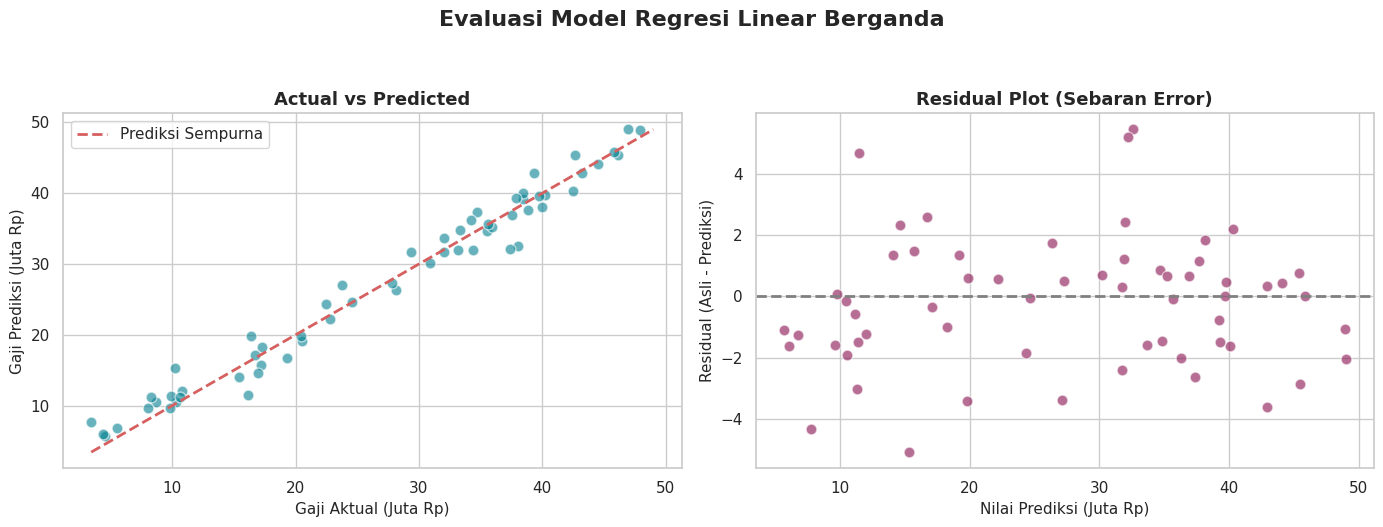

In [50]:
# ── 5. VISUALISASI STANDAR REGRESI ────────────────────────────────────
print("=== LANGKAH 5: VISUALISASI EVALUASI (Actual vs Prediksi & Residual) ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='#028090', edgecolors='white', s=60)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (Juta Rp)', fontsize=11)
axes[0].set_ylabel('Gaji Prediksi (Juta Rp)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='#880E4F', edgecolors='white', s=60)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi (Juta Rp)', fontsize=11)
axes[1].set_ylabel('Residual (Asli - Prediksi)', fontsize=11)
axes[1].set_title('Residual Plot (Sebaran Error)', fontsize=13, fontweight='bold')

plt.suptitle('Evaluasi Model Regresi Linear Berganda', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Interpretasi Langkah 5: Plot Evaluasi Regresi


*   A. Actual vs Predicted Plot
1.   What?: Titik-titik data (biru) menempel dengan sangat rapat dan membentuk garis lurus yang mengikuti jalur garis putus-putus merah (garis prediksi sempurna).
2.   So what?: Hal ini membuktikan bahwa akurasi model dalam memprediksi (predicted) sangat konsisten dengan data di dunia nyata (actual). Model berhasil menangkap pola utama tanpa ada penyimpangan signifikan.
3.   Now what?: Karena model terbukti presisi, kita dapat mendistribusikannya (deploy) agar tim rekrutmen dapat menggunakannya sebagai kalkulator otomatis untuk menentukan batas (range) gaji penawaran kandidat baru.

*   B. Residual Plot
1.   What?: Titik-titik error (residual) tersebar secara acak di sekitar garis horizontal (nilai nol) dan tidak membentuk pola tertentu seperti terompet/corong (melebar di ujung) atau pola melengkung (huruf U).
2.   So what?: Sebaran acak ini membuktikan bahwa asumsi Homoskedastisitas terpenuhi; varians tingkat kesalahan model kita stabil dan tidak semakin memburuk ketika ia menebak gaji karyawan tingkat bawah (junior) maupun tingkat atas (senior).
3.   Now what?: Tidak diperlukan lagi modifikasi matematis seperti transformasi non-linear atau fungsi logaritma, algoritma regresi linear standar sudah lebih dari cukup dan sempurna untuk dataset ini.
